_Copyright (C) 2024 Jagger Alexander_

_This program is free software: you can redistribute it and/or modify it as published._

_This program is distributed in the hope that it will be informative, but without any warranty; without even the implied warranty of merchantability or fitness for a particular purpose._

### Analyze data to prepare for ML-based heat wave prediction

1. Import necessary packages
2. Import merged data for prediction
3. Analyze data for multicollinearity
4. Optimize parameters using grid search

In [15]:
#1. Import necessary packages
#---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier

In [7]:
#2. Import merged data for prediction
#---

file_path = r'C:\Users\17753\Documents\Ch1Data\merged_df2.csv'

prediction_df = pd.read_csv(file_path)

# Display the columns of the dataframe
print(prediction_df.columns)

# Define the target: tmax_avg > t85_clim_smoothed (boolean)
prediction_df['target'] = prediction_df['tmax_avg'] > prediction_df['t85_clim_smoothed']

# Drop columns that won't be used for predictions (target variables)
X = prediction_df.drop(columns=[
    'tmax_avg', 'tmax_clim', 'tmax_clim_smoothed', 
    't85_clim', 't90_clim_smoothed', 't90_clim', 
    'target', 'DATE', 'MaxHourlyDryBulbTemperature'
])

# Define the target variable
y = prediction_df['target']

Index(['DATE', 'MaxHourlyDryBulbTemperature', 'tmax_avg', 'tmax_clim',
       'tmax_clim_smoothed', 't85_clim', 't85_clim_smoothed', 't90_clim',
       't90_clim_smoothed', 'dz_x_250_21d', 'dz_x_250_24d', 'dz_x_250_28d',
       'dz_y_250_21d', 'dz_y_250_24d', 'dz_y_250_28d', 'z_aus_250_21d',
       'z_aus_250_24d', 'z_aus_250_28d', 'avg_dz_x_250_21d',
       'avg_dz_x_250_24d', 'avg_dz_x_250_28d', 'avg_dz_y_250_21d',
       'avg_dz_y_250_24d', 'avg_dz_y_250_28d', 'dz_x_500_21d', 'dz_x_500_24d',
       'dz_x_500_28d', 'dz_y_500_21d', 'dz_y_500_24d', 'dz_y_500_28d',
       'z_aus_500_21d', 'z_aus_500_24d', 'z_aus_500_28d', 'avg_dz_x_500_21d',
       'avg_dz_x_500_24d', 'avg_dz_x_500_28d', 'avg_dz_y_500_21d',
       'avg_dz_y_500_24d', 'avg_dz_y_500_28d', 'dz_x_850_21d', 'dz_x_850_24d',
       'dz_x_850_28d', 'dz_y_850_21d', 'dz_y_850_24d', 'dz_y_850_28d',
       'z_aus_850_21d', 'z_aus_850_24d', 'z_aus_850_28d', 'avg_dz_x_850_21d',
       'avg_dz_x_850_24d', 'avg_dz_x_850_28d', 'avg_dz_y

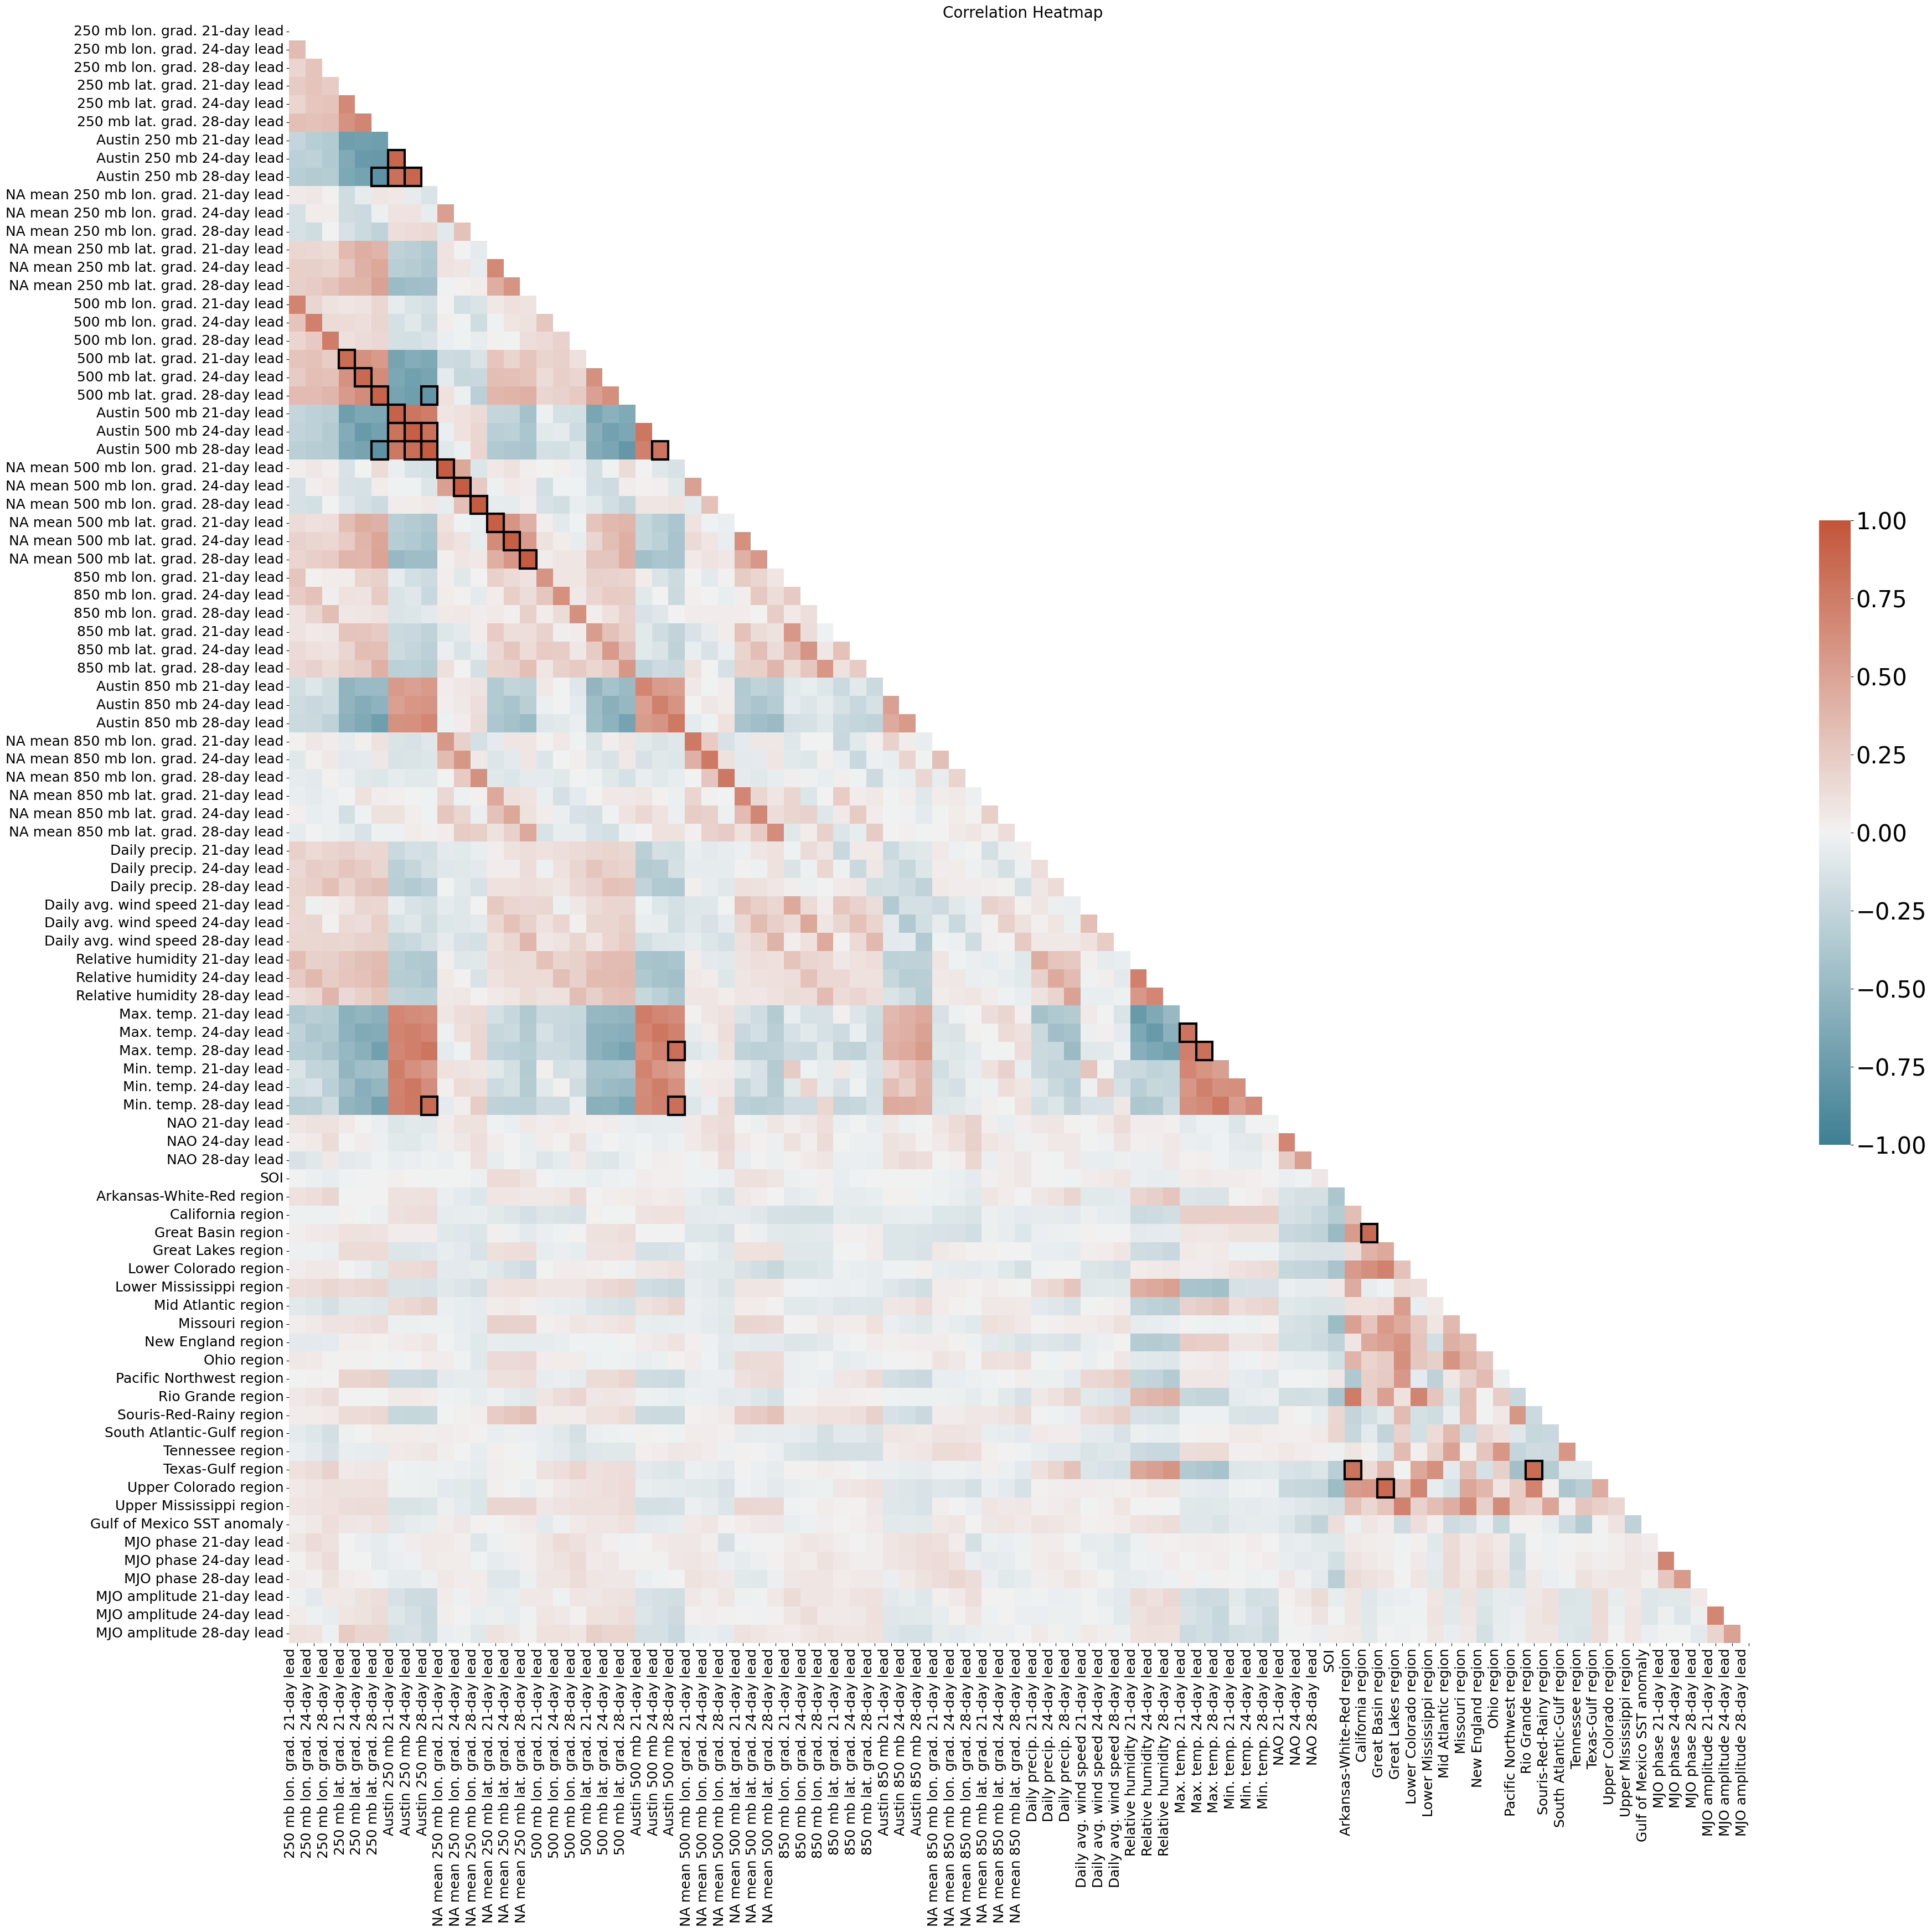

In [14]:
#3. Analyze data for multicollinearity
#---

# Drop the 'DATE' column
df = prediction_df.drop(columns=['DATE', 'MaxHourlyDryBulbTemperature', 'tmax_avg'])

# Remove columns containing "clim", "MaxHourlyDryBulbTemperature", and "target"
df = df.loc[:, ~df.columns.str.contains('clim|target')]

# Feature name mapping as provided
feature_name_mapping = {
    't85_clim_smoothed': 'Smoothed 85th Percentile Maximum Temperature Climatology',
    'dz_x_250_21d': '250 mb lon. grad. 21-day lead',
    'dz_x_250_24d': '250 mb lon. grad. 24-day lead',
    'dz_x_250_28d': '250 mb lon. grad. 28-day lead',
    'dz_y_250_21d': '250 mb lat. grad. 21-day lead',
    'dz_y_250_24d': '250 mb lat. grad. 24-day lead',
    'dz_y_250_28d': '250 mb lat. grad. 28-day lead',
    'dz_x_500_21d': '500 mb lon. grad. 21-day lead',
    'dz_x_500_24d': '500 mb lon. grad. 24-day lead',
    'dz_x_500_28d': '500 mb lon. grad. 28-day lead',
    'dz_y_500_21d': '500 mb lat. grad. 21-day lead',
    'dz_y_500_24d': '500 mb lat. grad. 24-day lead',
    'dz_y_500_28d': '500 mb lat. grad. 28-day lead',
    'dz_x_850_21d': '850 mb lon. grad. 21-day lead',
    'dz_x_850_24d': '850 mb lon. grad. 24-day lead',
    'dz_x_850_28d': '850 mb lon. grad. 28-day lead',
    'dz_y_850_21d': '850 mb lat. grad. 21-day lead',
    'dz_y_850_24d': '850 mb lat. grad. 24-day lead',
    'dz_y_850_28d': '850 mb lat. grad. 28-day lead',
    'z_aus_250_21d': 'Austin 250 mb 21-day lead',
    'z_aus_250_24d': 'Austin 250 mb 24-day lead',
    'z_aus_250_28d': 'Austin 250 mb 28-day lead',
    'z_aus_500_21d': 'Austin 500 mb 21-day lead',
    'z_aus_500_24d': 'Austin 500 mb 24-day lead',
    'z_aus_500_28d': 'Austin 500 mb 28-day lead',
    'z_aus_850_21d': 'Austin 850 mb 21-day lead',
    'z_aus_850_24d': 'Austin 850 mb 24-day lead',
    'z_aus_850_28d': 'Austin 850 mb 28-day lead',
    'avg_dz_x_250_21d': 'NA mean 250 mb lon. grad. 21-day lead',
    'avg_dz_x_250_24d': 'NA mean 250 mb lon. grad. 24-day lead',
    'avg_dz_x_250_28d': 'NA mean 250 mb lon. grad. 28-day lead',
    'avg_dz_y_250_21d': 'NA mean 250 mb lat. grad. 21-day lead',
    'avg_dz_y_250_24d': 'NA mean 250 mb lat. grad. 24-day lead',
    'avg_dz_y_250_28d': 'NA mean 250 mb lat. grad. 28-day lead',
    'avg_dz_x_500_21d': 'NA mean 500 mb lon. grad. 21-day lead',
    'avg_dz_x_500_24d': 'NA mean 500 mb lon. grad. 24-day lead',
    'avg_dz_x_500_28d': 'NA mean 500 mb lon. grad. 28-day lead',
    'avg_dz_y_500_21d': 'NA mean 500 mb lat. grad. 21-day lead',
    'avg_dz_y_500_24d': 'NA mean 500 mb lat. grad. 24-day lead',
    'avg_dz_y_500_28d': 'NA mean 500 mb lat. grad. 28-day lead',
    'avg_dz_x_850_21d': 'NA mean 850 mb lon. grad. 21-day lead',
    'avg_dz_x_850_24d': 'NA mean 850 mb lon. grad. 24-day lead',
    'avg_dz_x_850_28d': 'NA mean 850 mb lon. grad. 28-day lead',
    'avg_dz_y_850_21d': 'NA mean 850 mb lat. grad. 21-day lead',
    'avg_dz_y_850_24d': 'NA mean 850 mb lat. grad. 24-day lead',
    'avg_dz_y_850_28d': 'NA mean 850 mb lat. grad. 28-day lead',
    'DailyPrecipitation_21d': 'Daily precip. 21-day lead',
    'DailyPrecipitation_24d': 'Daily precip. 24-day lead',
    'DailyPrecipitation_28d': 'Daily precip. 28-day lead',
    'DailyAverageWindSpeed_21d': 'Daily avg. wind speed 21-day lead',
    'DailyAverageWindSpeed_24d': 'Daily avg. wind speed 24-day lead',
    'DailyAverageWindSpeed_28d': 'Daily avg. wind speed 28-day lead',
    'RelativeHumidity_21d': 'Relative humidity 21-day lead',
    'RelativeHumidity_24d': 'Relative humidity 24-day lead',
    'RelativeHumidity_28d': 'Relative humidity 28-day lead',
    'MinHourlyDryBulbTemperature_21d': 'Min. temp. 21-day lead',
    'MinHourlyDryBulbTemperature_24d': 'Min. temp. 24-day lead',
    'MinHourlyDryBulbTemperature_28d': 'Min. temp. 28-day lead',
    'MaxHourlyDryBulbTemperature_21d': 'Max. temp. 21-day lead',
    'MaxHourlyDryBulbTemperature_24d': 'Max. temp. 24-day lead',
    'MaxHourlyDryBulbTemperature_28d': 'Max. temp. 28-day lead',
    'amplitude_21d': 'MJO amplitude 21-day lead',
    'amplitude_24d': 'MJO amplitude 24-day lead',
    'amplitude_28d': 'MJO amplitude 28-day lead',
    'phase_21d': 'MJO phase 21-day lead',
    'phase_24d': 'MJO phase 24-day lead',
    'phase_28d': 'MJO phase 28-day lead',
    'NAO_21d': 'NAO 21-day lead',
    'NAO_24d': 'NAO 24-day lead',
    'NAO_28d': 'NAO 28-day lead',
    'SOI_34d': 'SOI',
    'Arkansas-White-Red Region_34d': 'Arkansas-White-Red region',
    'California Region_34d': 'California region',
    'Great Basin Region_34d': 'Great Basin region',
    'Great Lakes Region_34d': 'Great Lakes region',
    'Lower Colorado Region_34d': 'Lower Colorado region',
    'Lower Mississippi Region_34d': 'Lower Mississippi region',
    'Mid Atlantic Region_34d': 'Mid Atlantic region',
    'Missouri Region_34d': 'Missouri region',
    'New England Region_34d': 'New England region',
    'Ohio Region_34d': 'Ohio region',
    'Pacific Northwest Region_34d': 'Pacific Northwest region',
    'Rio Grande Region_34d': 'Rio Grande region',
    'Souris-Red-Rainy Region_34d': 'Souris-Red-Rainy region',
    'South Atlantic-Gulf Region_34d': 'South Atlantic-Gulf region',
    'Tennessee Region_34d': 'Tennessee region',
    'Texas-Gulf Region_34d': 'Texas-Gulf region',
    'Upper Colorado Region_34d': 'Upper Colorado region',
    'Upper Mississippi Region_34d': 'Upper Mississippi region',
    'anom_34d': 'Gulf of Mexico SST anomaly'
}

# Rename the columns using the mapping
df.rename(columns=feature_name_mapping, inplace=True)

# Calculate the correlation matrix
corr = df.corr()

# Set up the color palette (red to blue centered at 0)
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Create the heatmap without a colorbar instance
plt.figure(figsize=(35, 35))
heatmap = sns.heatmap(corr, annot=False, fmt=".2f", cmap=cmap, 
                      center=0, linewidths=0, linecolor='black', mask=mask, 
                      vmin=-1, vmax=1,  cbar_kws={'fraction': 0.02, 'pad': 0.04})

# Highlight correlations greater than 0.8 or less than -0.8
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8 and not mask[i, j]:
            heatmap.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3))
colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=30)  # Adjust the font size of the colorbar

# Adjust the x and y ticks for better visibility
plt.xticks(rotation=90, ha='right', fontsize=18)
plt.yticks(rotation=0, fontsize=18)
plt.title('Correlation Heatmap', fontsize=20)
plt.tight_layout()
d
# Save the heatmap as a PNG file
plt.savefig('correlation_heatmap.png', dpi=300)

# Show the heatmap
plt.show()


In [16]:
#4. Optimize parameters using grid search
#WARNING: May run very slowly/use significant processing; you can skip this step and use preset parameter values.
#---

# Define the model
model = XGBClassifier(scale_pos_weight=11.3) #set as the ratio of negative to positive class (i.e. target=FALSE/target=TRUE)

# Define the larger parameter grid
param_grid = {
    'n_estimators': [50, 100, 150, 200],  # Number of trees
    'max_depth': [3, 4, 5],   # Maximum depth of trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
    'subsample': [0.6, 0.7, 0.8, 0.9],         # Fraction of samples to be used for each tree
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],  # Fraction of features to be used for each tree
    'gamma': [0.1, 0.2, 0.3],          # Minimum loss reduction required to make a further partition
}

# Set up the StratifiedKFold cross-validation
cv = StratifiedKFold(n_splits=4, shuffle=True)

# Set up the GridSearchCV
grid_search = GridSearchCV(estimator=model, 
                           param_grid=param_grid, 
                           scoring='f1', 
                           cv=cv, 
                           verbose=1, 
                           n_jobs=-1)

# Fit the model with the grid search
grid_search.fit(X, y)

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)

Fitting 4 folds for each of 2304 candidates, totalling 9216 fits


C:\Users\17753\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [22:27:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters found:  {'colsample_bytree': 0.7, 'gamma': 0.3, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.9}
Best F1 score:  0.7309826339682464
